<a href="https://colab.research.google.com/github/rathibaral/Supply-Volatility-and-Food-Bank-Network-Optimization-for-Selected-Iowa-Counties/blob/main/Supply_Volatility_and_Food_Bank_Network_Optimization_A_Scenario_Based_Analysis_Using_USDA_Availability_Data.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [4]:

#1Import/install the libraries (pandas, numpy, matplotlib, PuLP, requests, zipfile, io)
#libraries for data handling, visualization, optimization, and web access
#configure plotting defaults and dataframe display settings for readability.

import io
import zipfile
import requests
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import pulp as pl

plt.rcParams["figure.figsize"] = (8, 5)
pd.set_option("display.max_columns", 50)


In [5]:
#2Downloading Loss-Adjusted Food Availability (LAFA) data csv from USDA
#load the CSV into a pandas DataFrame, and inspect structure and sample rows.

lafa_grains_url = ("https://ers.usda.gov/sites/default/files/_laserfiche/DataFiles/50472/grain.csv?v=49552")
resp = requests.get(lafa_grains_url)
resp.raise_for_status()
lafa_grains = pd.read_csv(io.StringIO(resp.text))

#inspecting the dataset for figuring out which columns are available to work with

print("LAFA grains data shape:", lafa_grains.shape)
print("Columns:", lafa_grains.columns.tolist())
print("\nLAFA Grains csv information: ")
display(lafa_grains.info())
display(lafa_grains.head())
display(lafa_grains.tail())


LAFA grains data shape: (9825, 4)
Columns: ['Commodity', 'Year', 'Attribute', 'Value']

LAFA Grains csv information: 
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 9825 entries, 0 to 9824
Data columns (total 4 columns):
 #   Column     Non-Null Count  Dtype  
---  ------     --------------  -----  
 0   Commodity  9825 non-null   object 
 1   Year       9825 non-null   int64  
 2   Attribute  9825 non-null   object 
 3   Value      9729 non-null   float64
dtypes: float64(1), int64(1), object(2)
memory usage: 307.2+ KB


None

,Commodity,Year,Attribute,Value
0,Grains: Per capita availability adjusted for loss,1970,Primary weight-Lbs/year,136.704320
1,Grains: Per capita availability adjusted for loss,1971,Primary weight-Lbs/year,134.668188
2,Grains: Per capita availability adjusted for loss,1972,Primary weight-Lbs/year,133.155463
3,Grains: Per capita availability adjusted for loss,1973,Primary weight-Lbs/year,136.992791
4,Grains: Per capita availability adjusted for loss,1974,Primary weight-Lbs/year,135.624051


,Commodity,Year,Attribute,Value
9820,Durum flour: Per capita availability adjusted ...,2018,Food pattern equivalents available daily-Oz-eq,0.347596
9821,Durum flour: Per capita availability adjusted ...,2019,Food pattern equivalents available daily-Oz-eq,0.350337
9822,Durum flour: Per capita availability adjusted ...,2020,Food pattern equivalents available daily-Oz-eq,0.389347
9823,Durum flour: Per capita availability adjusted ...,2021,Food pattern equivalents available daily-Oz-eq,0.334714
9824,Durum flour: Per capita availability adjusted ...,2022,Food pattern equivalents available daily-Oz-eq,0.357938


In [6]:
#3Inspecting suitable unique categories
#Inspect unique Commodity and Attribute categories in the LAFA dataset to identify valid supply measures for analysis.


print("Unique values in Commodity column:")
display(pd.Series(lafa_grains["Commodity"].dropna().unique()))

print("\nUnique values in Attribute column:")
display(pd.Series(lafa_grains["Attribute"].dropna().unique()))


Unique values in Commodity column:


,0
0,Grains: Per capita availability adjusted for loss
1,Wheat flour: Per capita availability adjusted ...
2,Rice: Per capita availability adjusted for loss
3,Rye flour: Per capita availability adjusted fo...
4,Corn: Per capita availability adjusted for loss
5,Corn flour and meal: Per capita availability a...
6,Corn hominy and grits: Per capita availability...
7,Corn starch: Per capita availability adjusted ...
8,Barley products: Per capita availability adjus...
9,Oat products: Per capita availability adjusted...



Unique values in Attribute column:


,0
0,Primary weight-Lbs/year
1,Retail weight-Lbs/year
2,Consumer weight-Lbs/year
3,"Total loss, all levels-Percent"
4,Per capita availability adjusted for loss-Lbs/...
5,Per capita availability adjusted for loss-Oz/day
6,Per capita availability adjusted for loss-G/day
7,Calories available daily-Number
8,Food pattern equivalents available daily-Oz-eq
9,Edible weight-Lbs/year


In [7]:
#4Picking one commodity(grains) and one attribute(loss-adjusted availability) for LAFA grains supply series
#filtering the dataset down to only necessities the LAFA dataset accordingly, clean numeric fields, and construct a yearly supply time series preview

commodity_choice = "Grains: Per capita availability adjusted for loss"
attribute_choice = "Per capita availability adjusted for loss-G/day"

print("Selected commodity:", commodity_choice)
print("Selected attribute:", attribute_choice)

available_commodities = set(lafa_grains["Commodity"].dropna().astype(str).unique())
available_attributes = set(lafa_grains["Attribute"].dropna().astype(str).unique())

if commodity_choice not in available_commodities:
    raise ValueError(f"Commodity not found: {commodity_choice}")

if attribute_choice not in available_attributes:
    raise ValueError(f"Attribute not found: {attribute_choice}")

#filtered LAFA data added to the chosen commodity and attribute, df_supply
df_supply = lafa_grains[
    (lafa_grains["Commodity"] == commodity_choice) &
    (lafa_grains["Attribute"] == attribute_choice)].copy()

df_supply["Value"] = pd.to_numeric(df_supply["Value"], errors="coerce")
df_supply["Year"] = pd.to_numeric(df_supply["Year"], errors="coerce")

df_supply = df_supply.dropna(subset=["Year", "Value"])
df_supply = df_supply.sort_values("Year").reset_index(drop=True)

if df_supply.empty:
    raise ValueError("Commodity/Attribute do not match exactly.")

#Preview of the resulting supply time series
print("\nSupply time series preview:")
display(df_supply.head(10))

print("Years covered:", int(df_supply["Year"].min()), "to", int(df_supply["Year"].max()))


Selected commodity: Grains: Per capita availability adjusted for loss
Selected attribute: Per capita availability adjusted for loss-G/day

Supply time series preview:


,Commodity,Year,Attribute,Value
0,Grains: Per capita availability adjusted for loss,1970,Per capita availability adjusted for loss-G/day,117.788215
1,Grains: Per capita availability adjusted for loss,1971,Per capita availability adjusted for loss-G/day,116.129495
2,Grains: Per capita availability adjusted for loss,1972,Per capita availability adjusted for loss-G/day,114.816335
3,Grains: Per capita availability adjusted for loss,1973,Per capita availability adjusted for loss-G/day,118.096076
4,Grains: Per capita availability adjusted for loss,1974,Per capita availability adjusted for loss-G/day,116.880323
5,Grains: Per capita availability adjusted for loss,1975,Per capita availability adjusted for loss-G/day,119.692505
6,Grains: Per capita availability adjusted for loss,1976,Per capita availability adjusted for loss-G/day,123.893620
7,Grains: Per capita availability adjusted for loss,1977,Per capita availability adjusted for loss-G/day,120.290271
8,Grains: Per capita availability adjusted for loss,1978,Per capita availability adjusted for loss-G/day,123.022248
9,Grains: Per capita availability adjusted for loss,1979,Per capita availability adjusted for loss-G/day,124.256214


Years covered: 1970 to 2022


In [8]:
#5Compute mean availability and volatility of the grain supply series using the coefficient of variation
#then translate volatility into a heuristic bad-year supply reduction factor.


supply_series = df_supply["Value"]

mean_supply = supply_series.mean()
std_supply = supply_series.std()

#Coefficient of Variation for measuring volatility
cv_supply = std_supply / mean_supply if mean_supply != 0 else np.nan

#CV-based bad factor multiplier as a heuristic technique
bad_factor = max(0.5, 1.0 - cv_supply) if pd.notna(cv_supply) else 0.7

print("Supply volatility using the physical availability of grains, measured as grams per person per day, adjusted for losses.")
print("Mean availability:", mean_supply)
print("Std dev:", std_supply)
print("CV (std/mean):", cv_supply)
print("Bad-year multiplier (bad_factor):", bad_factor)


Supply volatility using the physical availability of grains, measured as grams per person per day, adjusted for losses.
Mean availability: 147.65463996037738
Std dev: 18.149089821343075
CV (std/mean): 0.12291581101828782
Bad-year multiplier (bad_factor): 0.8770841889817121


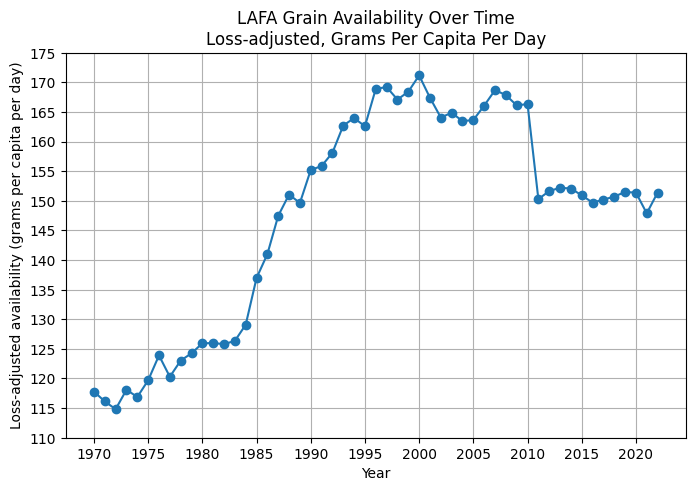

In [9]:
#6historical time series of loss-adjusted per-capita grain availability
#Visualize historical loss-adjusted per-capita grain availability over time
#with formatted axes to highlight long-run supply patterns.

plt.figure()
plt.title("LAFA Grain Availability Over Time\n""Loss-adjusted, Grams Per Capita Per Day")
plt.plot(df_supply["Year"], df_supply["Value"], marker="o")
plt.xlabel("Year")
plt.ylabel("Loss-adjusted availability (grams per capita per day)")

years = df_supply["Year"].values
plt.xticks(np.arange(years.min(), years.max() + 1, 5))

values = df_supply["Value"].values
y_min = np.floor(values.min() / 5) * 5
y_max = np.ceil(values.max() / 5) * 5
plt.yticks(np.arange(y_min, y_max + 1, 5))

plt.grid(True)
plt.show()

In [10]:
#7Download and unzip the USDA Food Environment Atlas,
#load the data table, filter to Iowa counties, clean identifiers,
#and identify food insecurity variables for demand modeling.


atlas_zip_url = ("https://ers.usda.gov/sites/default/files/_laserfiche/DataFiles/113063/2025-food-environment-atlas-data.zip?v=94310")

resp = requests.get(atlas_zip_url)
resp.raise_for_status()

with zipfile.ZipFile(io.BytesIO(resp.content)) as z:
    csv_files = [n for n in z.namelist() if n.lower().endswith(".csv")]
    if not csv_files:
        raise ValueError("No CSV files found in Food Environment Atlas ZIP.")
    with z.open(csv_files[0]) as f:
        atlas_df = pd.read_csv(f)

print("Columns in Food Environment Atlas data:")
display(pd.Index(atlas_df.columns))

required_cols = {"State", "Variable_Code", "Value"}
missing = required_cols - set(atlas_df.columns)
if missing:
    raise ValueError(f"Missing required columns: {missing}")

iowa_all = atlas_df.loc[atlas_df["State"] == "IA"].copy()

print("Rows for Iowa:", len(iowa_all))

iowa_all["Variable_Code"] = iowa_all["Variable_Code"].astype(str).str.strip()

foodinsec_codes = sorted(
    c for c in iowa_all["Variable_Code"].unique()
    if "FOODINSEC" in c.upper())

print("Food insecurity-related codes found:", foodinsec_codes)

demand_variable_code = "FOODINSEC_21_23"
if demand_variable_code not in foodinsec_codes:
    raise ValueError(
        f"Demand variable '{demand_variable_code}' not found."
        f"Available FOODINSEC codes: {foodinsec_codes}")

iowa_df = iowa_all.loc[
    iowa_all["Variable_Code"] == demand_variable_code,
    ["FIPS", "State", "County", "Variable_Code", "Value"]].copy()

print(f"Rows after filtering for {demand_variable_code}:", len(iowa_df))
display(iowa_df.head(10).reset_index(drop=True))


Columns in Food Environment Atlas data:


Index(['FIPS', 'State', 'County', 'Variable_Code', 'Value'], dtype='object')

Rows for Iowa: 30096
Food insecurity-related codes found: ['CH_FOODINSEC_20_23', 'FOODINSEC_18_20', 'FOODINSEC_21_23']
Rows after filtering for FOODINSEC_21_23: 99


,FIPS,State,County,Variable_Code,Value
0,19001.0,IA,Adair,FOODINSEC_21_23,9.8
1,19003.0,IA,Adams,FOODINSEC_21_23,9.8
2,19005.0,IA,Allamakee,FOODINSEC_21_23,9.8
3,19007.0,IA,Appanoose,FOODINSEC_21_23,9.8
4,19009.0,IA,Audubon,FOODINSEC_21_23,9.8
5,19011.0,IA,Benton,FOODINSEC_21_23,9.8
6,19013.0,IA,Black Hawk,FOODINSEC_21_23,9.8
7,19015.0,IA,Boone,FOODINSEC_21_23,9.8
8,19017.0,IA,Bremer,FOODINSEC_21_23,9.8
9,19019.0,IA,Buchanan,FOODINSEC_21_23,9.8


In [11]:
#8Construct county-level demand by combining USDA food insecurity rates with ACS population data
#reshape population data from wide to long format, map counties to FIPS codes
#merge datasets, compute population-weighted demand, select the highest-need counties and normalize total demand to a fixed scale for optimization.

required_cols = {"FIPS", "County", "Variable_Code", "Value"}
missing = required_cols - set(iowa_all.columns)
if missing:
    raise ValueError(f"iowa_all missing columns: {sorted(missing)}")

iowa_all = iowa_all.copy()
iowa_all["FIPS"] = iowa_all["FIPS"].astype(str).str.zfill(5)
iowa_all["County"] = iowa_all["County"].astype(str).str.strip()
iowa_all["Variable_Code"] = iowa_all["Variable_Code"].astype(str).str.strip()

demand_code = "FOODINSEC_21_23"

iowa_foodinsec = iowa_all.loc[iowa_all["Variable_Code"] == demand_code,["FIPS", "County", "Value"]].rename(columns={"Value": "food_insec_rate"})

iowa_foodinsec["food_insec_rate"] = pd.to_numeric(iowa_foodinsec["food_insec_rate"], errors="coerce")
iowa_foodinsec = iowa_foodinsec.dropna(subset=["food_insec_rate"])

if iowa_foodinsec.empty:
    raise ValueError(f"No usable rows for demand_code = {demand_code}")

acs_raw = pd.read_csv("/content/ACS IOWA pop.csv")

county_est_cols = [c for c in acs_raw.columns if c.endswith("!!Estimate") and "County" in c]

if not county_est_cols:
    raise ValueError("No county-level '!!Estimate' columns found in ACS file.")

acs_long = acs_raw[county_est_cols].T.reset_index()
acs_long.columns = ["county_label", "population"]

acs_long["County"] = (acs_long["county_label"].astype(str).str
                      .replace("County, Iowa!!Estimate", "", regex=False).str.strip())

acs_long["population"] = pd.to_numeric(acs_long["population"].astype(str).str.replace(",", "", regex=False),errors="coerce")

acs_long = acs_long.dropna(subset=["population"])
acs_long = acs_long[acs_long["population"] > 0]

#Attach FIPS to avoid duplicate county results
county_fips_map = (iowa_all[["FIPS", "County"]].drop_duplicates().copy())

acs_pop = acs_long.merge(county_fips_map, on="County", how="left")

if acs_pop["FIPS"].isna().any():
    bad = acs_pop.loc[acs_pop["FIPS"].isna(), "County"].tolist()[:10]
    raise ValueError(f"Could not map FIPS for some counties: {bad}")

acs_pop = acs_pop[["FIPS", "population"]].drop_duplicates()

#Merge population into food insecurity table

iowa_demand = iowa_foodinsec.merge(acs_pop, on="FIPS", how="inner")

if iowa_demand.empty:
    raise ValueError("No counties matched between food insecurity and ACS population.")

#Computing raw demand
iowa_demand["raw_demand"] = (iowa_demand["food_insec_rate"] / 100.0) * iowa_demand["population"]

demand_nodes = (iowa_demand.sort_values("raw_demand", ascending=False).head(5).reset_index(drop=True))

#Setting total demand unit to 200
target_total_demand = 200.0
raw_sum = demand_nodes["raw_demand"].sum()
if raw_sum <= 0:
    raise ValueError("raw_demand sum <= 0; cannot scale.")

demand_nodes["demand_units"] = (demand_nodes["raw_demand"] * (target_total_demand / raw_sum))

display(demand_nodes[["FIPS", "County", "food_insec_rate", "population", "raw_demand", "demand_units"]])

print("\nTotal demand units:", demand_nodes["demand_units"].sum())


,FIPS,County,food_insec_rate,population,raw_demand,demand_units
0,19153.0,Polk,9.8,497441,48749.218,83.830365
1,19113.0,Linn,9.8,229463,22487.374,38.669846
2,19163.0,Scott,9.8,174302,17081.596,29.373936
3,19103.0,Johnson,9.8,154881,15178.338,26.101047
4,19013.0,Black Hawk,9.8,130693,12807.914,22.024807



Total demand units: 199.99999999999997


In [12]:
#9Aggregate county demand to system-level demand
#defining warehouse supply under a normal year with buffer capacity
#and apply a volatility-based supply shock to generate a bad-year scenario.
#Bad-year total supply: apply system-wide supply shock
#bad_factor is interpreted as a supply availability multiplier (< 1 in bad years)

#allocate total supply across assumed warehouses
warehouses = ["DesMoines", "CedarRapids"]

#Total demand from county demand nodes(scaled units from Block 8)
total_demand = float(demand_nodes["demand_units"].sum())

#Normal-year total supply: 5% buffer added above total demand
normal_supply_total = total_demand * 1.05
bad_supply_total = normal_supply_total * bad_factor

print("Total demand (scaled units):", total_demand)
print("Normal-year total supply (scaled units):", normal_supply_total)
print("Bad-year total supply (scaled units):", bad_supply_total)


hub_split = {"DesMoines": 0.6, "CedarRapids": 0.4}

normal_supply = {w: normal_supply_total * hub_split[w]
                 for w in warehouses}

bad_supply = {w: bad_supply_total * hub_split[w]
              for w in warehouses}

print("\nNormal-year supply by warehouse:")
print({k: float(v) for k, v in normal_supply.items()})

print("\nBad-year supply by warehouse:")
print({k: float(v) for k, v in bad_supply.items()})


Total demand (scaled units): 199.99999999999997
Normal-year total supply (scaled units): 209.99999999999997
Bad-year total supply (scaled units): 184.18767968615953

Normal-year supply by warehouse:
{'DesMoines': 125.99999999999997, 'CedarRapids': 84.0}

Bad-year supply by warehouse:
{'DesMoines': 110.51260781169572, 'CedarRapids': 73.67507187446381}


In [13]:
#10Transport cost matrix (stylized, order-independent)
#Purpose: Introduce asymmetric shipping costs between warehouses and counties
#to create meaningful trade-offs in a small toy network.
#Disclaimer: Costs are RELATIVE and UNITLESS (not miles or dollars)
#Closeness is randomly assigned (reproducible), not geographic
#It is a stylized, asymmetric transport cost matrix between warehouses and counties
#using a reproducible proximity assignment to create meaningful allocation trade-offs.


import random

#Demand counties
counties = demand_nodes["County"].astype(str).tolist()
print("Demand counties:", counties)

#Assumed warehouses
warehouses = ["DesMoines", "CedarRapids"]

#Initialize transport cost dictionary
transport_cost = {w: {} for w in warehouses}

#Stylized closeness assignment, randomly assign each county to be "closer" to one warehouse.
#This avoids dependence on county ordering and keeps results reproducible.

random.seed(42)  # fixed seed for reproducibility
random.shuffle(counties)

split_point = max(1, len(counties) // 2)
dm_closer = counties[:split_point]
cr_closer = counties[split_point:]

print("Counties treated as closer to Des Moines:", dm_closer)
print("Counties treated as closer to Cedar Rapids:", cr_closer)

#Relative shipping costs
#Lower cost= cheaper shipping
#These numbers are chosen only to enforce trade-offs (toy model)

LOW_COST = 3
HIGH_COST = 6

for county in counties:
    transport_cost["DesMoines"][county] = (LOW_COST if county in dm_closer else HIGH_COST)
    transport_cost["CedarRapids"][county] = (LOW_COST if county in cr_closer else HIGH_COST)

#cost matrix (rows = warehouses, columns = counties)
cost_df = pd.DataFrame(transport_cost).T[counties]

print("\nStylized transport cost matrix (relative units):")
display(cost_df)


Demand counties: ['Polk', 'Linn', 'Scott', 'Johnson', 'Black Hawk']
Counties treated as closer to Des Moines: ['Johnson', 'Linn']
Counties treated as closer to Cedar Rapids: ['Scott', 'Black Hawk', 'Polk']

Stylized transport cost matrix (relative units):


,Johnson,Linn,Scott,Black Hawk,Polk
DesMoines,3,3,6,6,6
CedarRapids,6,6,3,3,3


Total Demand(scaled units): 199.99999999999997

Normal Scenario Status: Optimal | objective: 753.68732844
Bad Scenario Status: Optimal | objective: 16502.1081901

Flows (Normal):


,warehouse,county,shipped
0,CedarRapids,Polk,83.830365
1,CedarRapids,Scott,0.169635
2,DesMoines,Black Hawk,22.024807
3,DesMoines,Johnson,26.101047
4,DesMoines,Linn,38.669846
5,DesMoines,Scott,29.204301



Flows (Bad):


,warehouse,county,shipped
0,CedarRapids,Polk,68.018044
1,CedarRapids,Scott,5.657028
2,DesMoines,Black Hawk,22.024807
3,DesMoines,Johnson,26.101047
4,DesMoines,Linn,38.669846
5,DesMoines,Scott,23.716909



Service Table (Normal):


,demand,shipped,unmet,service_ratio
County,,,,
Johnson,26.101047,26.101047,0.0,1.0
Linn,38.669846,38.669846,0.0,1.0
Scott,29.373936,29.373936,0.0,1.0
Black Hawk,22.024807,22.024807,0.0,1.0
Polk,83.830365,83.830365,0.0,1.0



Service Table (Bad):


,demand,shipped,unmet,service_ratio
County,,,,
Johnson,26.101047,26.101047,0.00000,1.000000
Linn,38.669846,38.669846,0.00000,1.000000
Scott,29.373936,29.373937,0.00000,1.000000
Black Hawk,22.024807,22.024807,0.00000,1.000000
Polk,83.830365,68.018044,15.81232,0.811377



Scenario Summary: 


,scenario,status,total_demand,total_shipped,total_unmet,objective
0,Normal,Optimal,200.0,200.000001,0.00000,753.687328
1,Bad,Optimal,200.0,184.187681,15.81232,16502.108190


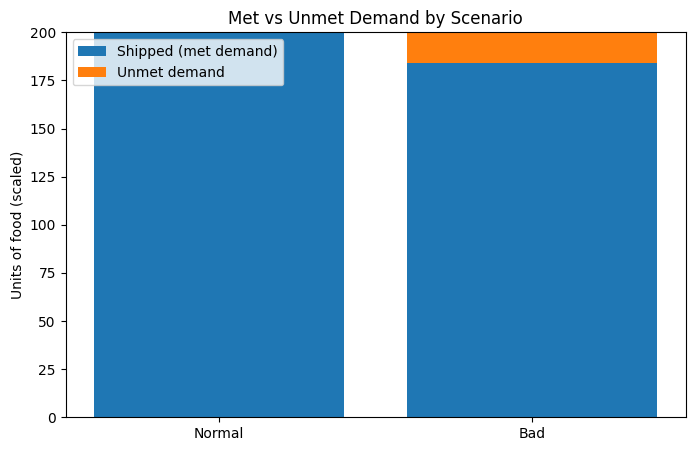

In [14]:
#11food bank network optimization model
#decision variables = shipments from each warehouse to each county + unmet demand per county
#objective = minimize total transport cost plus a large penalty on unmet demand
#constraints = warehouse supply limits and county demand balance
#solve the model under Normal and Bad supply scenarios and extract flows and service outcomes


def solve_foodbank_lp_with_unmet(warehouses, counties, demand_series,
                                 supply_dict, cost_dict, unmet_penalty=1000.0,
                                 scenario_name="Scenario"):
    prob = pl.LpProblem(f"FoodBank_{scenario_name}", pl.LpMinimize)
    ship = pl.LpVariable.dicts("ship", [(w, c) for w in warehouses for c in counties], lowBound=0)
    unmet = pl.LpVariable.dicts("unmet", counties, lowBound=0)
    prob += (pl.lpSum(cost_dict[w][c] * ship[(w, c)] for w in warehouses for c in counties) + unmet_penalty * pl.lpSum(unmet[c] for c in counties))

    for w in warehouses:
        prob += pl.lpSum(ship[(w, c)] for c in counties) <= float(supply_dict[w])

    for c in counties:
        prob += pl.lpSum(ship[(w, c)] for w in warehouses) + unmet[c] == float(demand_series[c])

    prob.solve(pl.PULP_CBC_CMD(msg=False))

    status = pl.LpStatus[prob.status]
    obj_val = float(pl.value(prob.objective)) if pl.value(prob.objective) is not None else np.nan

    flows = [{"warehouse": w, "county": c, "shipped": float(ship[(w, c)].value())}
             for w in warehouses
             for c in counties
             if ship[(w, c)].value() is not None and ship[(w, c)].value() > 1e-8]


    flows_df = pd.DataFrame(flows)

    unmet_df = pd.DataFrame({"county": counties, "unmet": [float(unmet[c].value() or 0.0) for c in counties]}).set_index("county")

    return status, obj_val, flows_df, unmet_df



def served_table(demand_series, flows_df, unmet_df):
    shipped = (flows_df.groupby("county")["shipped"].sum()
        if not flows_df.empty
        else pd.Series(0.0, index=demand_series.index))

    shipped = shipped.reindex(demand_series.index, fill_value=0.0)

    out = pd.DataFrame({"demand": demand_series, "shipped": shipped})
    out["unmet"] = unmet_df["unmet"].reindex(demand_series.index).fillna(0.0)
    out["service_ratio"] = out["shipped"] / out["demand"].replace(0, np.nan)

    return out


#Demand series aligned to the counties list used by the cost matrix
demand_series = (demand_nodes.set_index("County")["demand_units"].reindex(counties).fillna(0.0))

print("Total Demand(scaled units):", float(demand_series.sum()))

#both scenarios in a small loop to avoid repetition
scenarios = [("Normal", normal_supply),("Bad", bad_supply)]

results = {}
for name, supply in scenarios:
    results[name] = solve_foodbank_lp_with_unmet(warehouses=warehouses, counties=counties,
                                                 demand_series=demand_series, supply_dict=supply,
                                                 cost_dict=transport_cost, unmet_penalty=1000.0,
                                                 scenario_name=name)

#Unpack
status_norm, obj_norm, flows_norm, unmet_norm = results["Normal"]
status_bad, obj_bad, flows_bad, unmet_bad = results["Bad"]

#Served tables
served_norm = served_table(demand_series, flows_norm, unmet_norm)
served_bad = served_table(demand_series, flows_bad, unmet_bad)

print("\nNormal Scenario Status:", status_norm, "| objective:", obj_norm)
print("Bad Scenario Status:", status_bad, "| objective:", obj_bad)

print("\nFlows (Normal):")
display(flows_norm.sort_values(["warehouse", "county"]).reset_index(drop=True) if not flows_norm.empty else flows_norm)

print("\nFlows (Bad):")
display(flows_bad.sort_values(["warehouse", "county"]).reset_index(drop=True) if not flows_bad.empty else flows_bad)

print("\nService Table (Normal):")
display(served_norm)

print("\nService Table (Bad):")
display(served_bad)

summary = pd.DataFrame({"scenario": ["Normal", "Bad"],
                        "status": [status_norm, status_bad],
                        "total_demand": [float(demand_series.sum()), float(demand_series.sum())],
                        "total_shipped": [float(served_norm["shipped"].sum()), float(served_bad["shipped"].sum())],
                        "total_unmet": [float(served_norm["unmet"].sum()), float(served_bad["unmet"].sum())],
                        "objective": [obj_norm, obj_bad]})

print("\nScenario Summary: ")
display(summary)

fig, ax = plt.subplots()
ax.bar(summary["scenario"], summary["total_shipped"], label="Shipped (met demand)")
ax.bar(summary["scenario"], summary["total_unmet"], bottom=summary["total_shipped"], label="Unmet demand")
ax.set_ylabel("Units of food (scaled)")
ax.set_title("Met vs Unmet Demand by Scenario")
ax.legend()
plt.show()


In [15]:
#12Consolidate county-level and scenario-level results,
#interpreting demand construction, supply shocks, and optimization outcomes. Also, generating a concise narrative.

county_index = demand_series.index.astype(str)
served_norm_aligned = served_norm.reindex(county_index)
served_bad_aligned  = served_bad.reindex(county_index)

#County-level results table (Normal vs Bad only)
county_results = pd.DataFrame({"County": county_index,
    "Demand_units": demand_series.values,

    "Normal_shipped": served_norm_aligned["shipped"].values,
    "Normal_unmet": served_norm_aligned["unmet"].values,
    "Normal_service_ratio": served_norm_aligned["service_ratio"].values,

    "Bad_shipped": served_bad_aligned["shipped"].values,
    "Bad_unmet": served_bad_aligned["unmet"].values,
    "Bad_service_ratio": served_bad_aligned["service_ratio"].values})

county_results = county_results.sort_values("Demand_units", ascending=False).reset_index(drop=True)
print("\nCounty-level Results:")
display(county_results)

#Scenario summary table (from `summary` in the solve block)
if "summary" not in globals():
    raise ValueError("Expected `summary` DataFrame not found. Run the LP solve block first.")

summary_out = summary.copy()
summary_out["pct_demand_met"] = summary_out["total_shipped"] / summary_out["total_demand"].replace(0, np.nan)
summary_out["pct_unmet"] = summary_out["total_unmet"] / summary_out["total_demand"].replace(0, np.nan)

print("\nScenario Summary:")
display(summary_out)

#Short narrative
demand_code_text = (demand_variable_code if "demand_variable_code" in globals()
    else (demand_code if "demand_code" in globals() else "FOODINSEC_21_23"))

acs_source_text = "ACS county population (B01003 Total Population, reshaped from CSV)"

interpretation_text = f"""
Supply Volatility & Food Bank Optimization (Iowa)

Demand:
County demand = (food insecurity rate × ACS population),
using {demand_code_text}, scaled to ~200 total units for a tractable network.

Supply:
LAFA grain availability volatility summarized by CV = {cv_supply:.3f},
mapped to bad_factor = {bad_factor:.3f} for the bad-year supply shock.

Model:
Transportation LP minimizes shipping cost plus a high penalty on unmet demand,
solved under (1) Normal supply (5% buffer) and (2) Bad supply (volatility-driven reduction).""".strip()

print("\nShort Narrative\n")
print(interpretation_text)



County-level Results:


,County,Demand_units,Normal_shipped,Normal_unmet,Normal_service_ratio,Bad_shipped,Bad_unmet,Bad_service_ratio
0,Polk,83.830365,83.830365,0.0,1.0,68.018044,15.81232,0.811377
1,Linn,38.669846,38.669846,0.0,1.0,38.669846,0.00000,1.000000
2,Scott,29.373936,29.373936,0.0,1.0,29.373937,0.00000,1.000000
3,Johnson,26.101047,26.101047,0.0,1.0,26.101047,0.00000,1.000000
4,Black Hawk,22.024807,22.024807,0.0,1.0,22.024807,0.00000,1.000000



Scenario Summary:


,scenario,status,total_demand,total_shipped,total_unmet,objective,pct_demand_met,pct_unmet
0,Normal,Optimal,200.0,200.000001,0.00000,753.687328,1.000000,0.000000
1,Bad,Optimal,200.0,184.187681,15.81232,16502.108190,0.920938,0.079062



Short Narrative

Supply Volatility & Food Bank Optimization (Iowa)

Demand:
County demand = (food insecurity rate × ACS population),
using FOODINSEC_21_23, scaled to ~200 total units for a tractable network.

Supply:
LAFA grain availability volatility summarized by CV = 0.123,
mapped to bad_factor = 0.877 for the bad-year supply shock.

Model:
Transportation LP minimizes shipping cost plus a high penalty on unmet demand,
solved under (1) Normal supply (5% buffer) and (2) Bad supply (volatility-driven reduction).
